#### Nama : Heni Artha Uli Br Turnip
#### NIM  : 121140080

## 1. Analisis Sinyal menggunakan FFT

- Muat sinyal yang ditugaskan dari file CSV
- Plot sinyal asli dalam domain waktu (time domain)
- Terapkan FFT untuk menganalisis komponen frekuensi
- Identifikasi dan dokumentasikan frekuensi yang paling dominan dalam sinyal Anda
- Plot spektrum frekuensi dan tandai frekuensi dominan

In [104]:
# Mengimport library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fft, signal
import datetime as dt
from scipy.signal import firwin, filtfilt, butter

In [105]:
# Muat data dari file CSV
file_path = '121140080_8_900.csv'
data = pd.read_csv(file_path)
signal = data.iloc[:, 0].values  # Ambil nilai sinyal dari kolom pertama

# Parameter analisis
duration = 8    # Durasi dalam detik
fs = 900        # Frekuensi sampling dalam Hz
T = 1 / fs      # Periode sampling

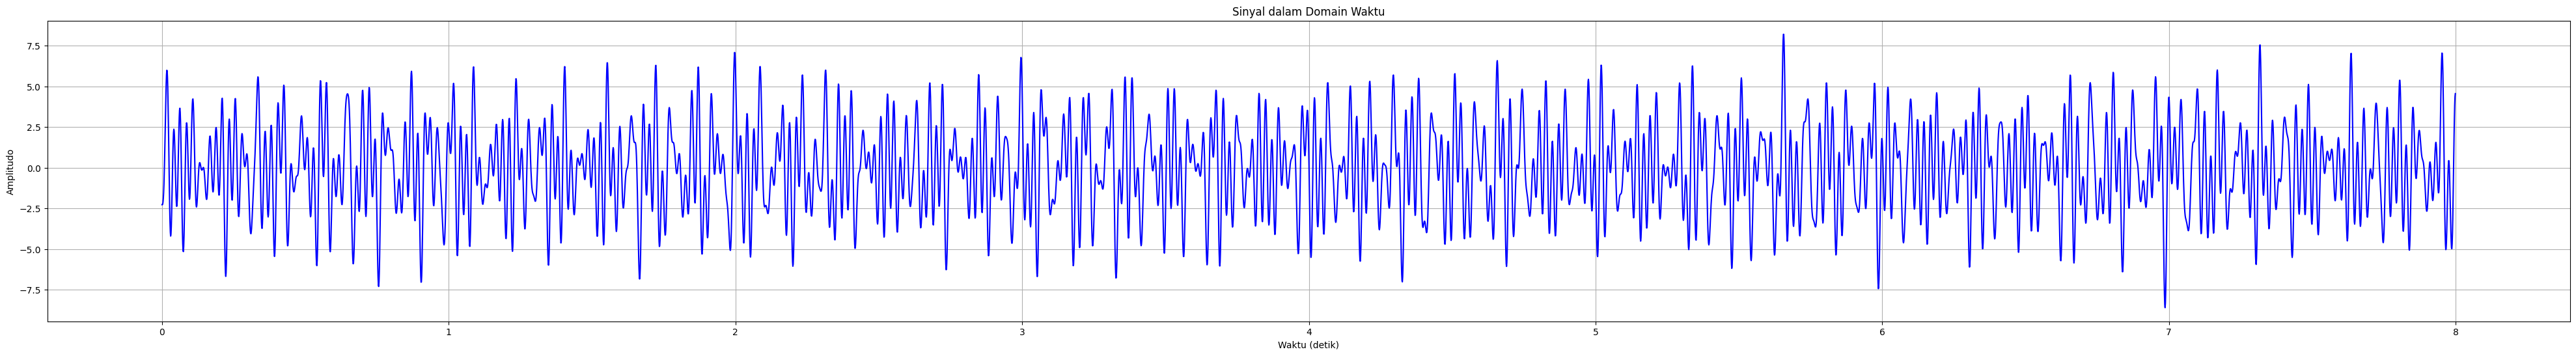

In [106]:
# Menampilkan sinyal dalam domain waktu
time = np.linspace(0, duration, len(signal), endpoint=False)

# Plot sinyal asli dalam domain waktu
plt.figure(figsize=(50, 6))
plt.plot(time, signal, color='blue')
plt.title('Sinyal dalam Domain Waktu')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True)
plt.show()

In [107]:
# Menghitung FFT menggunakan implementasi SciPy
def calculate_scipy_fft(signal, fs):
    """
    Menghitung FFT menggunakan implementasi SciPy.
    
    Parameters:
    signal (array): Sinyal input dalam domain waktu
    fs (float): Frekuensi sampling dalam Hz
    
    Returns:
    tuple: (frequencies, fft_result)
    """
    N = len(signal)
    fft_result = fft.fft(signal)  # Menghitung FFT
    frequencies = fft.fftfreq(N, d=1/fs)  # Menghitung sumbu frekuensi
    return frequencies, fft_result

In [108]:
# menghitung FFT dan menampilkan waktu yang dibutuhkan
waktu_mulai = dt.datetime.now()
frequencies, fft_result = calculate_scipy_fft(signal, fs)
waktu_selesai = dt.datetime.now()
waktu_proses = waktu_selesai - waktu_mulai
print(f"Proses filtering memakan waktu {waktu_proses.total_seconds()} detik")

Proses filtering memakan waktu 0.00103 detik


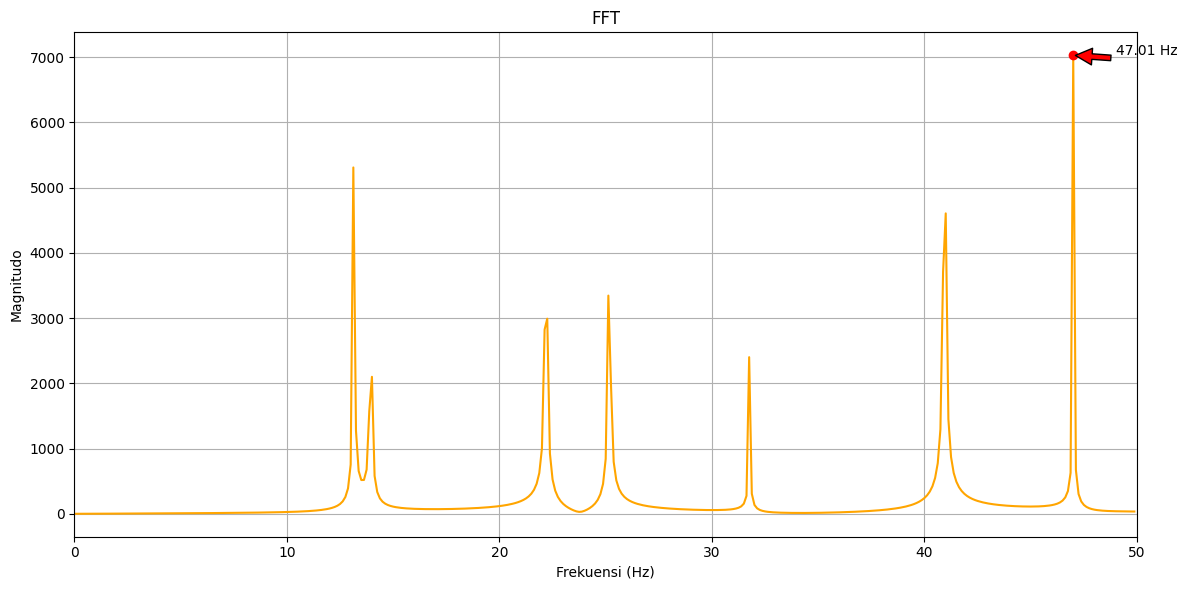

In [109]:
# Menampikan FFT dalam domain frekuensi
plt.figure(figsize=(12, 6))

# Filter frekuensi yang tidak relevan
freq_mask = (frequencies >= 0) & (frequencies <= 50)  

# Plot spektrum magnitudo
plt.plot(frequencies[freq_mask], np.abs(fft_result)[freq_mask], color='orange')
plt.title(f'FFT')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitudo')
plt.grid(True)
plt.xlim(0, 50)

# Tandai frekuensi dominan
dominant_freq = frequencies[np.argmax(np.abs(fft_result))]
dominant_magnitude = np.abs(fft_result).max()
plt.plot(dominant_freq, dominant_magnitude, 'ro')  # Titik merah pada frekuensi dominan
plt.annotate(f'{dominant_freq:.2f} Hz', xy=(dominant_freq, dominant_magnitude),
             xytext=(dominant_freq + 2, dominant_magnitude),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.tight_layout()
plt.show()

## Analisis Hasil No 1

Pada plot sinyal dalam domain waktu, kita dapat mengamati bagaimana amplitudo sinyal berubah seiring waktu. Ini memberikan gambaran umum tentang perilaku sinyal asli sebelum dilakukan analisis frekuensi. Dengan menerapkan FFT pada sinyal, kita dapat mengidentifikasi komponen frekuensi yang ada dalam sinyal tersebut. FFT mengubah sinyal dari domain waktu ke domain frekuensi, memungkinkan kita untuk melihat frekuensi mana yang paling dominan. Dari hasil FFT, frekuensi dominan yang teridentifikasi adalah sekitar 47.01 Hz dengan magnitudo sekitar 7000. Frekuensi ini ditandai dengan titik merah pada plot spektrum frekuensi. Frekuensi dominan ini menunjukkan komponen frekuensi yang paling kuat dalam sinyal.

Proses filtering memakan waktu 0.015555 detik


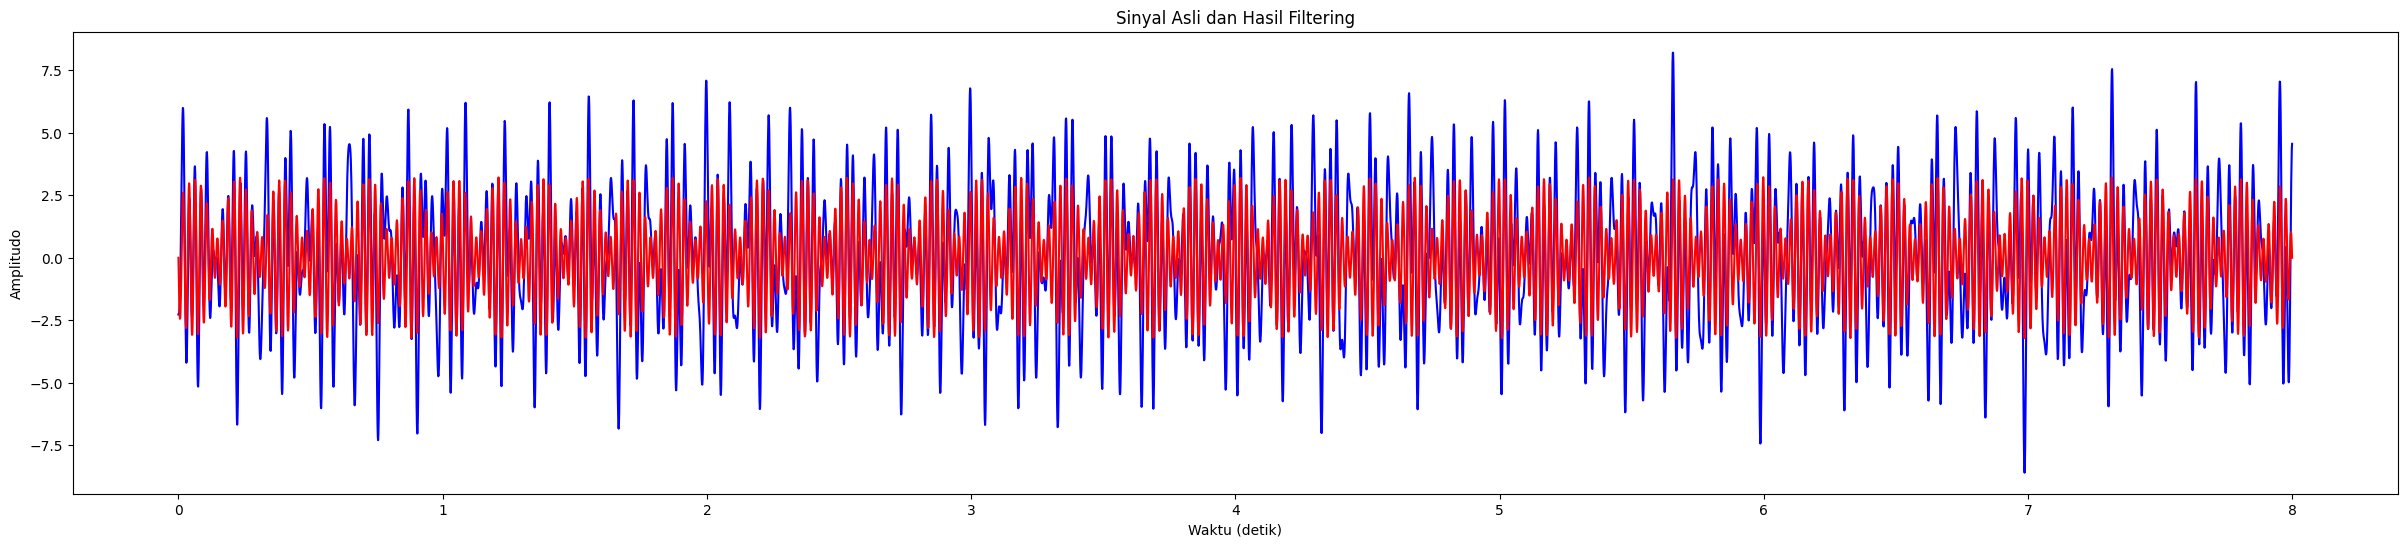

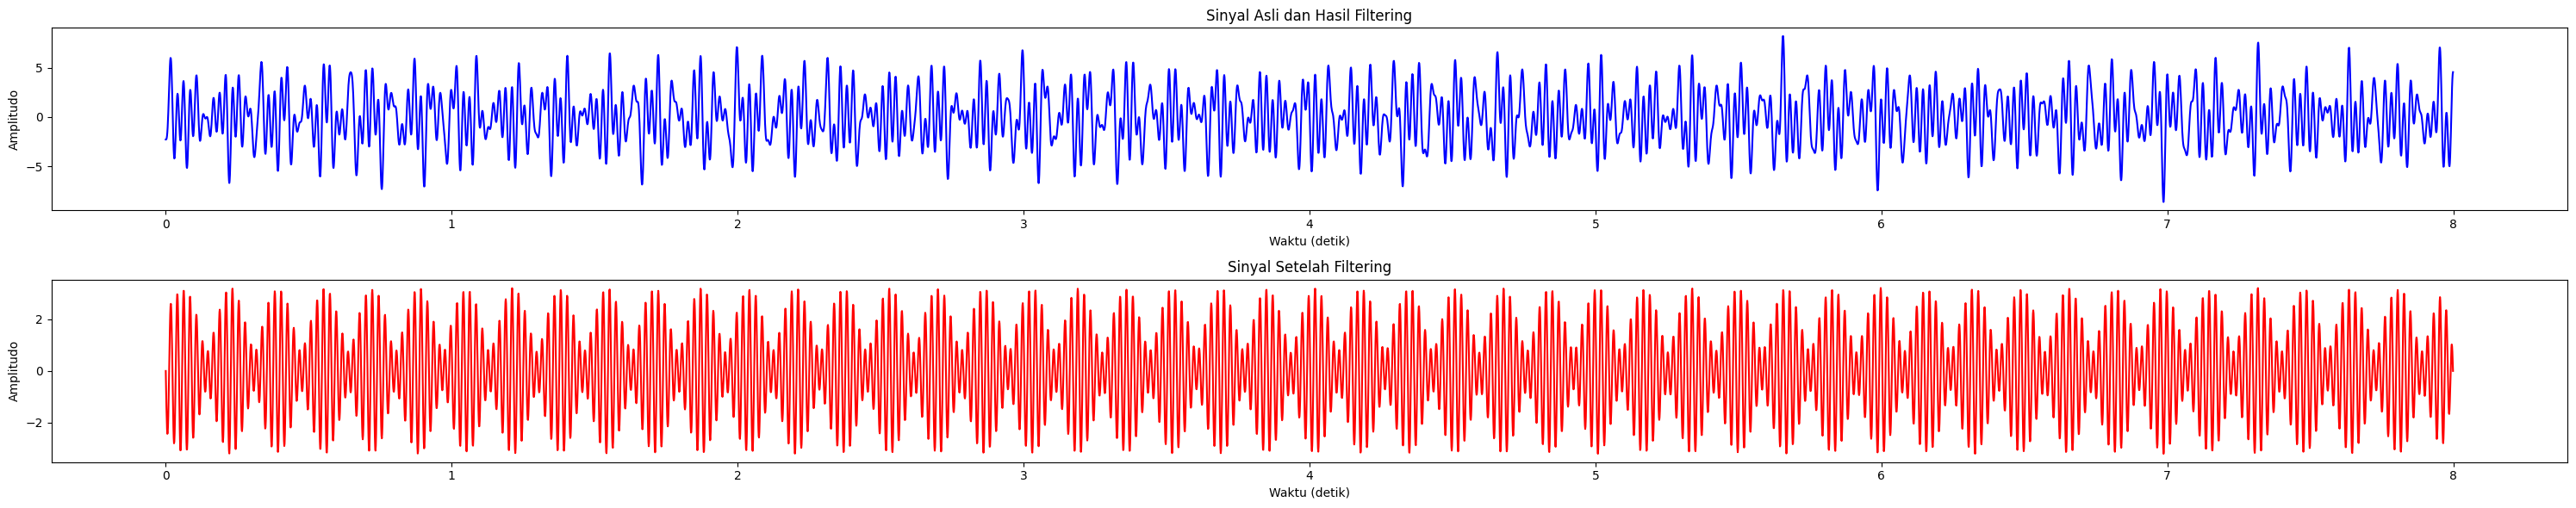

In [116]:
# Membuat filter FIR
lowcut = 37 # Hz
highcut = 57 # Hz

nyquist_rata = fs/2
lowcut_nyquist = lowcut/nyquist_rata
highcut_nyquist = highcut/nyquist_rata
fft_order = 100 # filter order (luas jendela)

fir_coeff = firwin(
    fft_order, 
    [lowcut_nyquist, highcut_nyquist], 
    pass_zero=False
)
waktu_mulai = dt.datetime.now()
filtered_fft_scipy_ecg = filtfilt(fir_coeff, 1, signal)
waktu_selesai = dt.datetime.now()
waktu_proses = waktu_selesai - waktu_mulai
print(f"Proses filtering memakan waktu {waktu_proses.total_seconds()} detik")

# Menampilkan hasil filtering
plt.figure(figsize=(30, 6))
plt.plot(time, signal, color='blue', label='Sinyal Asli')
plt.plot(time, filtered_fft_scipy_ecg, color='red', label='Sinyal Setelah Filtering')
plt.title('Sinyal Asli dan Hasil Filtering')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')

fig, ax = plt.subplots(2, 1, figsize=(30, 6))
ax[0].plot(time, signal, color='blue', label='Sinyal Asli')
ax[0].set_title('Sinyal Asli dan Hasil Filtering')
ax[0].set_xlabel('Waktu (detik)')
ax[0].set_ylabel('Amplitudo')

ax[1].plot(time, filtered_fft_scipy_ecg, color='red', label='Sinyal Setelah Filtering')
ax[1].set_title('Sinyal Setelah Filtering')
ax[1].set_xlabel('Waktu (detik)')
ax[1].set_ylabel('Amplitudo')


plt.tight_layout()
plt.show()


## 2. Filtering Sinyal

- Rancang dan implementasikan bandpass filter untuk mengisolasi frekuensi dominan
- Filter harus mempertahankan frekuensi dominan sambil meredam frekuensi lainnya
- Plot sinyal asli dan sinyal hasil filtering untuk perbandingan
- Bandingkan spektrum frekuensi sebelum dan sesudah filtering

In [110]:
# Membuat filter bandpass IIR
lowcut = 37   # Frekuensi batas bawah (disesuaikan) diberi jarak 10 Hz dari frekuensi dominan agar lebih aman
highcut = 57  # Frekuensi batas atas (disesuaikan) diberi jarak 10 Hz dari frekuensi dominan agar lebih aman
order = 3     # Orde filter

b, a = butter(order, [lowcut, highcut], btype='band', fs=fs)

waktu_mulai = dt.datetime.now()
filtered_signal = filtfilt(b, a, signal)
waktu_selesai = dt.datetime.now()
waktu_proses = waktu_selesai - waktu_mulai
print(f"Proses filtering memakan waktu {waktu_proses.total_seconds()} detik")


Proses filtering memakan waktu 0.0 detik


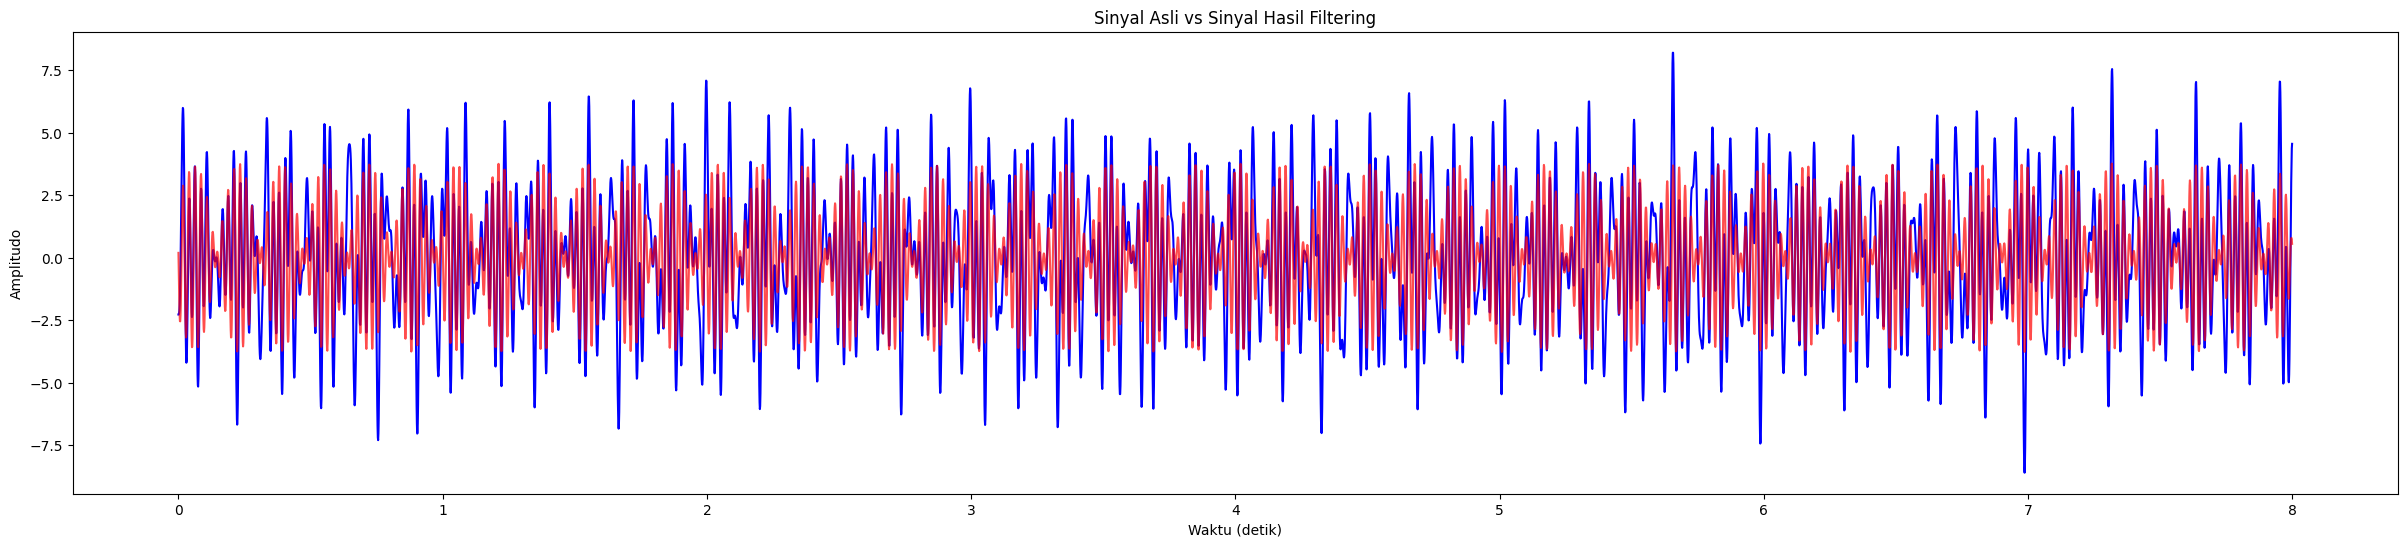

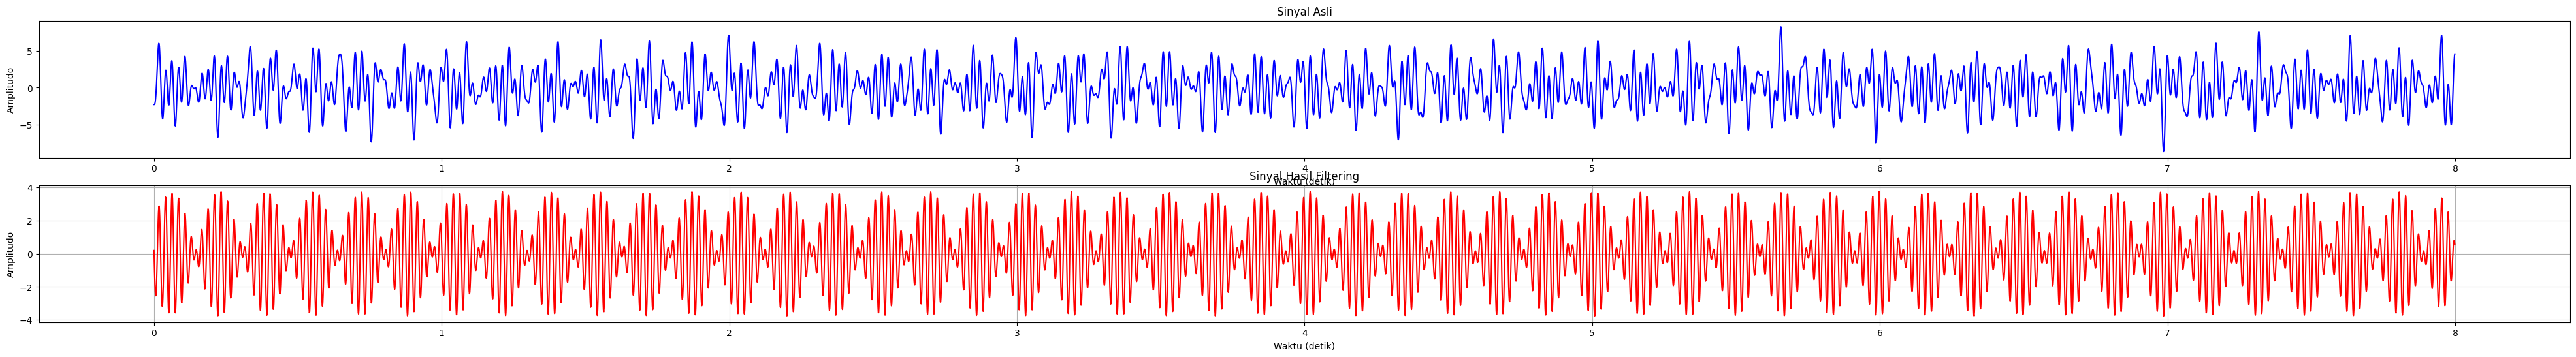

In [111]:
# Menampilkan sinyal asli dan hasil filtering dalam domain waktu
plt.figure(figsize=(30, 6))
plt.plot(time, signal, label='Sinyal Asli', color='blue')
plt.plot(time, filtered_signal, label='Sinyal Hasil Filtering', color='red', alpha=0.7)
plt.title('Sinyal Asli vs Sinyal Hasil Filtering')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')

fig, ax = plt.subplots(2, 1, figsize=(50, 6))
ax[0].plot(time, signal, color='blue')
ax[0].set_title('Sinyal Asli')
ax[0].set_xlabel('Waktu (detik)')
ax[0].set_ylabel('Amplitudo')

ax[1].plot(time, filtered_signal, color='red')
ax[1].set_title('Sinyal Hasil Filtering')
ax[1].set_xlabel('Waktu (detik)')
ax[1].set_ylabel('Amplitudo')

plt.grid(True)
plt.show()

## Analisis Perbedaan Hasil IIR dan FIR

1. **Domain Waktu**: (IIR Lebih cepat dibandingkan FIR)
    - Sinyal hasil filtering menggunakan filter FIR dan IIR menunjukkan bahwa kedua filter berhasil meredam frekuensi yang tidak diinginkan dan mempertahankan frekuensi dominan.
    - Filter FIR menghasilkan sinyal yang lebih halus dibandingkan dengan filter IIR.

2. **Domain Frekuensi**:(FIR lebih baik dalam meredam frekuensi yang tidak diinginkan)
    - Spektrum frekuensi sebelum dan sesudah filtering menunjukkan bahwa kedua filter berhasil mengisolasi frekuensi dominan sekitar 47 Hz.
    - Filter FIR menunjukkan pengurangan yang lebih pada komponen frekuensi lainnya dibandingkan dengan filter IIR.

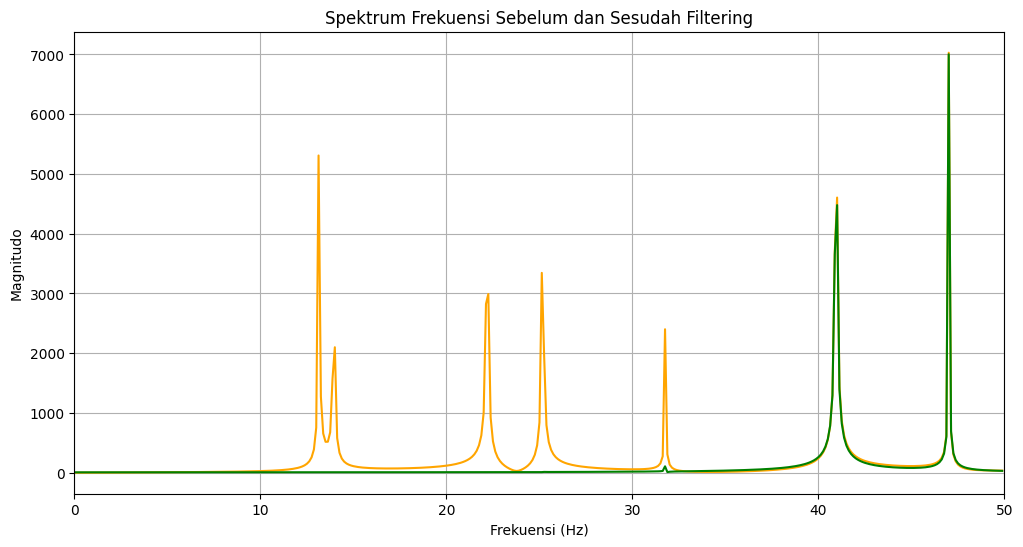

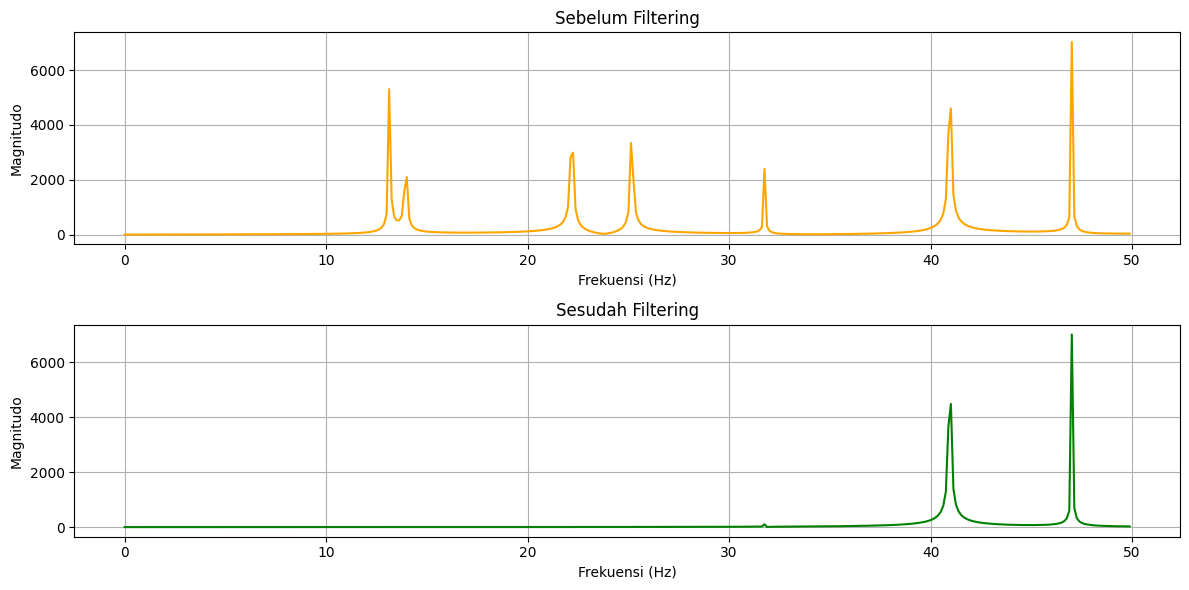

In [112]:
# Menghitung FFT dari sinyal yang telah difilter
frequencies_filtered, fft_result_filtered = calculate_scipy_fft(filtered_signal, fs)

# Plot spektrum frekuensi sebelum dan sesudah filtering
plt.figure(figsize=(12, 6))

# Plot spektrum magnitudo sebelum filtering
plt.plot(frequencies[freq_mask], np.abs(fft_result)[freq_mask], label='Sebelum Filtering', color='orange')

# Plot spektrum magnitudo sesudah filtering
plt.plot(frequencies_filtered[freq_mask], np.abs(fft_result_filtered)[freq_mask], label='Sesudah Filtering', color='green')

plt.title('Spektrum Frekuensi Sebelum dan Sesudah Filtering')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitudo')
plt.grid(True)
plt.xlim(0, 50)

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(frequencies[freq_mask], np.abs(fft_result)[freq_mask], color='orange')
ax[0].set_title('Sebelum Filtering')
ax[0].set_xlabel('Frekuensi (Hz)')
ax[0].set_ylabel('Magnitudo')
ax[0].grid(True)

ax[1].plot(frequencies_filtered[freq_mask], np.abs(fft_result_filtered)[freq_mask], color='green')
ax[1].set_title('Sesudah Filtering')
ax[1].set_xlabel('Frekuensi (Hz)')
ax[1].set_ylabel('Magnitudo')
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 3 Analisis Hasil diatas

Setelah itu, kita merancang dan mengimplementasikan filter bandpass IIR untuk mengisolasi frekuensi dominan tersebut. Filter ini dirancang dengan frekuensi batas bawah 37 Hz dan frekuensi batas atas 57 Hz, serta orde filter 3. Hasil filtering menunjukkan bahwa sinyal hasil filtering mempertahankan frekuensi dominan sambil meredam frekuensi lainnya.

Perbandingan spektrum frekuensi sebelum dan sesudah filtering menunjukkan bahwa frekuensi dominan tetap ada setelah filtering, sementara komponen frekuensi lainnya telah berkurang secara signifikan. Hal ini menunjukkan bahwa filter bandpass yang dirancang berhasil mengisolasi frekuensi dominan dengan baik.

Secara keseluruhan, analisis ini menunjukkan bahawa FFT dan filtering dapat digunakan untuk mengidentifikasi dan mengisolasi komponen frekuensi dalam sinyal. 

### Referensi

Github copilot dan modul